In [33]:
import time #时间处理标准库
import requests
from bs4 import BeautifulSoup
import pandas as pd
#start翻页,time.sleep休眠时间，模仿人类，user_agent更改

In [34]:
# 模拟浏览器头部信息，向豆瓣服务器发送消息
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                        'AppleWebKit/537.36 (KHTML, like Gecko) '
                        'Chrome/131.0.0.0 Safari/537.36 Edg/131.0.0.0'}
##爬取好评
target = "https://book.douban.com/subject/35406615/comments/?percent_type=&start=0&limit=20&status=P&sort=score&comments_only=1"

#爬取前3页的评论
max_pages = 4
comments = []
for page in range(max_pages):
    # 获取HTML页面信息
    response = requests.get(url = target
                            + '?start=' + str(page * 20)#遍历每一页的20条评论
                            , headers = headers
                            )
    response.encoding = 'utf-8'
    soup = BeautifulSoup(response.text, 'lxml')
    comment_elements = soup.find_all('span', {'class': 'short'})
    for element in comment_elements:
        comments.append(element.text.strip())
        time.sleep(1) #设置休眠时间，防止被检测
data = {'评论内容': comments}
df = pd.DataFrame(data)
df

,评论内容
0,人是怎么疯的：FIRST BLOOD：我瞧不起所有人。DOUBLE KILL：他们凭什么也瞧...
1,无须比较就可以感受到汝龙译本的精妙。就像余华说的，罪与罚把20岁的他炸得晕头转向，这本书也把...
2,绝对信仰崩塌的时代，生活与爱给予我们活下去的勇气。
3,罪与罚最好的中译本，装帧设计有审美。非常差的轻型纸，质感类似报纸，薄且粗糙，由于过于粗糙，整...
4,（读过几个国家的陀思妥耶夫斯基，现在终于开始读正宗版本的陀思妥耶夫斯基）这群疯狂、纠结与痛苦...
...,...
75,没有很get，到后期只迫切结束这段阅读... 可能是时代和语言的关系，我总感觉这些人物是遥远...
76,1.阅读卡拉马佐夫兄弟的过程，就像是一座山压在你的心上，而且越压越重；而阅读罪与罚的过程，就...
77,《卡拉马佐夫兄弟》有提到要爱具体的人，不要爱抽象的人。否则，就是本书主人公拉斯科尔尼科夫的结...
78,断断续续的漫长的阅读，第一次读陀，和想象中完全不一样，本以为他是个很古典的作家。虽然挺讨厌大...


In [35]:
import jieba
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [61]:
# 停用词列表
stopwords = set()

# 加载默认的停用词
with open('哈工大停用词表.txt', 'r', encoding='utf-8') as f:
    for line in f:
        stopwords.add(line.strip())

# 添加自定义的停用词
custom_stopwords = ["\n", "为什么", "作者"]
stopwords.update(custom_stopwords)

In [62]:

# 分词并去除停用词
filtered_words = []
for comment in comments:
    words = jieba.lcut(comment)
    for word in words:
        if word not in stopwords:
            filtered_words.append(word)

In [63]:
from collections import Counter

# 统计词频
word_counts = Counter(filtered_words)

# 打印词频最高的10个词
print(word_counts.most_common(10))

[('爱', 68), ('人', 48), ('不', 48), ('罪与罚', 32), ('没有', 32), ('都', 28), ('阅读', 24), ('不是', 24), ('去', 24), ('爱情', 24)]


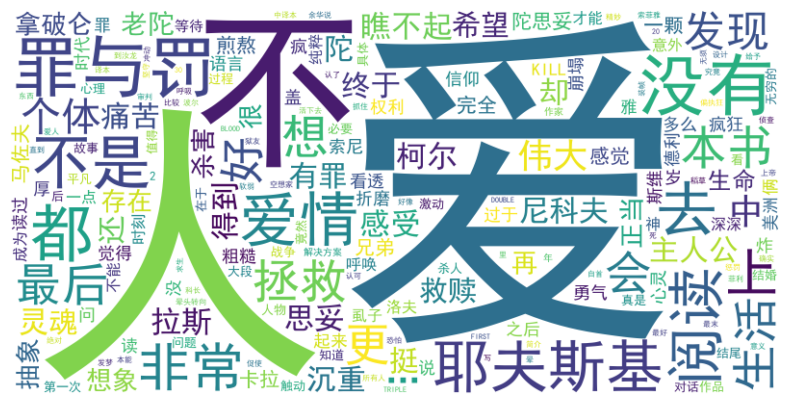

In [64]:
# 生成词云
wordcloud = WordCloud(font_path='simhei.ttf', width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# 显示词云
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [65]:
from snownlp import SnowNLP

In [66]:
import numpy as np

In [67]:
# 情感分析
sentiments = [SnowNLP(comment).sentiments for comment in comments]

In [68]:
# 划分分数段
bins = np.linspace(0, 1, 11)  # 0.0, 0.1, 0.2, ..., 1.0
hist, _ = np.histogram(sentiments, bins=bins)

# 打印分数段频率
for i, count in enumerate(hist):
    print(f"分数段 {bins[i]:.1f} - {bins[i+1]:.1f}: {count} 条")

分数段 0.0 - 0.1: 0 条
分数段 0.1 - 0.2: 0 条
分数段 0.2 - 0.3: 4 条
分数段 0.3 - 0.4: 0 条
分数段 0.4 - 0.5: 0 条
分数段 0.5 - 0.6: 0 条
分数段 0.6 - 0.7: 4 条
分数段 0.7 - 0.8: 4 条
分数段 0.8 - 0.9: 4 条
分数段 0.9 - 1.0: 64 条


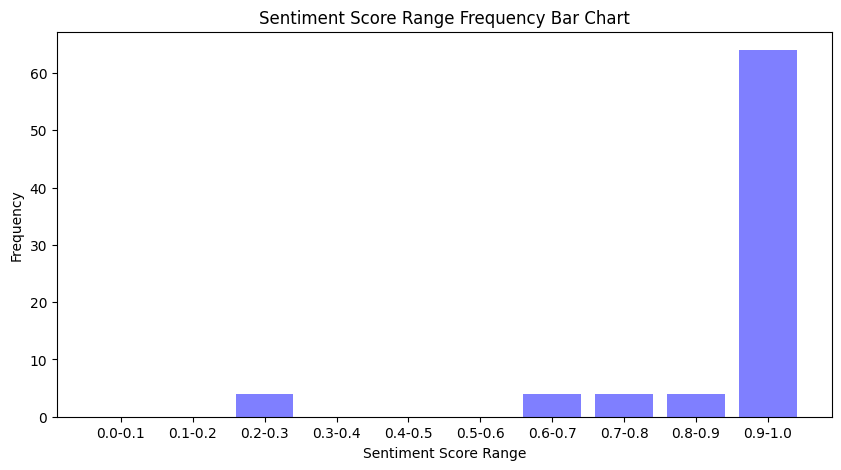

In [69]:
# 绘制柱状图
plt.figure(figsize=(10, 5))
plt.bar(np.arange(len(hist)), hist, align='center', alpha=0.5, color='b')
plt.xticks(np.arange(len(hist)), [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(hist))])
plt.xlabel('Sentiment Score Range')
plt.ylabel('Frequency')
plt.title('Sentiment Score Range Frequency Bar Chart')
plt.show()

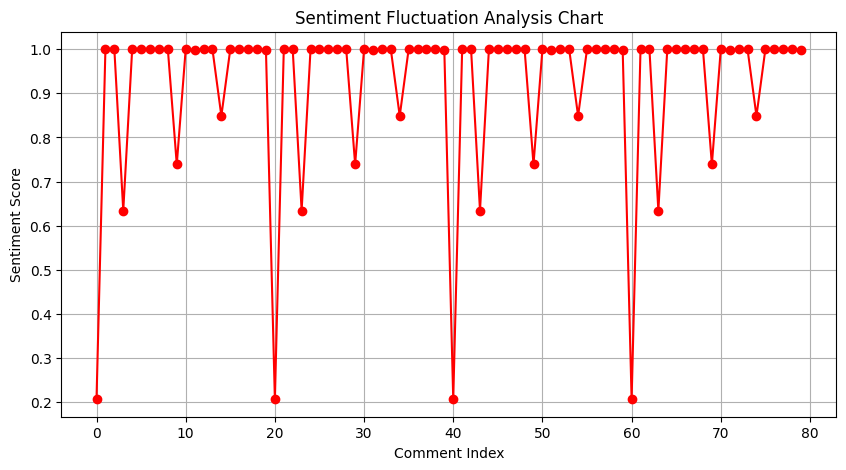

In [70]:
# 绘制情感波动分析图
plt.figure(figsize=(10, 5))
plt.plot(sentiments, marker='o', linestyle='-', color='r')
plt.xlabel('Comment Index')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Fluctuation Analysis Chart')
plt.grid(True)
plt.show()

In [71]:
# 计算均值和中位数
mean_sentiment = np.mean(sentiments)
median_sentiment = np.median(sentiments)

In [72]:
print(f"情感平均: {mean_sentiment:.2f}")
print(f"中位数: {median_sentiment:.2f}")

情感平均: 0.92
中位数: 1.00


In [73]:
# 将情感分数转换为类别标签
labels = np.array([1 if sentiment > 0.5 else 0 for sentiment in sentiments])

D:\Anaconda Mini\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda Mini\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


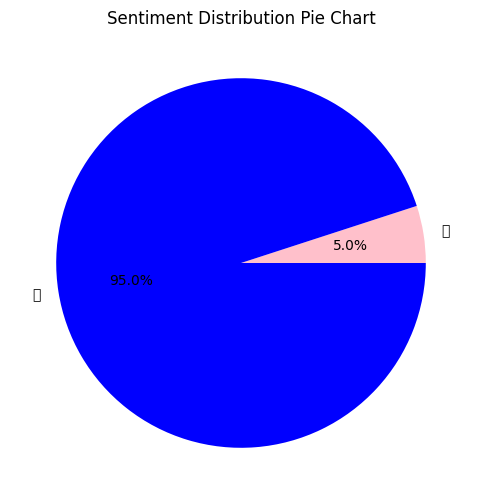

In [74]:
# 统计类别数量
unique, counts = np.unique(labels, return_counts=True)

# 绘制饼图
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=['差', '好'], autopct='%1.1f%%', colors=['pink', 'blue'])
plt.title('Sentiment Distribution Pie Chart')
plt.show()

In [75]:
from sklearn.model_selection import train_test_split

# 将评论数据转换为特征向量（这里简单使用评论文本作为特征）
X = np.array(comments)
y = labels

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=63)

In [76]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [77]:
# 特征提取
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [78]:
# 训练朴素贝叶斯模型
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_predictions = nb_model.predict(X_test_vec)

In [79]:
# 训练逻辑回归模型
lr_model = LogisticRegression(random_state=63)
lr_model.fit(X_train_vec, y_train)
lr_predictions = lr_model.predict(X_test_vec)

In [55]:
# 评估模型
def evaluate_model(predictions, model_name):
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    print(f"{model_name} Model Evaluation:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print()

In [56]:
evaluate_model(nb_predictions, "朴素贝叶斯")
evaluate_model(lr_predictions, "逻辑回归")

朴素贝叶斯 Model Evaluation:
Accuracy: 0.88
Precision: 1.00
Recall: 0.87
F1 Score: 0.93

逻辑回归 Model Evaluation:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

